# Метод главных компонент (PCA) — собственные данные

Работа состоит из двух частей и использует **другие датасеты**, чем в лекции:

---

### Часть 1. PCA для понижения размерности — данные о качестве вина

В лекции использовался датасет **Iris** (150 объектов, 4 признака, 3 класса).  
Здесь используется **Red Wine Quality** (1599 объектов, **11 признаков**, 2 класса качества).  
Большее число признаков делает задачу понижения размерности более содержательной: метод «локтя» покажет, сколько из 11 компонент достаточно для объяснения большей части дисперсии.

---

### Часть 2. Eigenfaces для распознавания лиц — LFW Dataset

В лекции использовался **Olivetti Faces** (`sklearn.datasets.fetch_olivetti_faces`):  
400 изображений, 40 человек по 10 фото каждый, **студийные условия** — нейтральный фон, контролируемое освещение, одинаковый масштаб.

В этой работе используется **Labeled Faces in the Wild (LFW)** (`sklearn.datasets.fetch_lfw_people`):  
Реальные фотографии из интернета — **разное освещение, позы, выражения лиц, фон**. Это существенно усложняет задачу распознавания по сравнению с лекционным примером и лучше отражает реальные условия применения метода eigenfaces.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_lfw_people

---
## Часть 1. PCA — данные о качестве вина

### Загрузка и подготовка данных

In [2]:
file_id = '1Sb3HGWMlKob3_-rEgqfudszz0ujhVTV9'
file_url = f'https://drive.google.com/uc?export=download&id={file_id}'
df = pd.read_csv(file_url)
df.columns = [c.replace(' ', '_') for c in df.columns]

feature_cols = [c for c in df.columns if c != 'quality']
y_wine = (df['quality'] >= 6).astype(int).values

# Стандартизация — обязательный шаг перед PCA
X_wine = StandardScaler().fit_transform(df[feature_cols].values)

print('Форма данных:', X_wine.shape)
print('Признаки:', feature_cols)

Форма данных: (1599, 11)
Признаки: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol']


### Класс PCA

In [3]:
class PCA:

  def __init__(self, n_components, solver='covariance'):
    self.n_components = n_components
    self.mean = None
    self.explained_variance = None
    self.solver = solver

  def fit(self, X):

    self.mean = np.mean(X, axis=0)

    if self.solver == 'covariance':
      covariances = (X - self.mean).T.dot((X - self.mean)) / (X.shape[0]-1)
      eigenvalues, eigenvectors = np.linalg.eig(covariances)

      idxs = np.argsort(eigenvalues)[::-1]
      eigenvalues = eigenvalues[idxs]
      eigenvectors = eigenvectors[idxs].T

    elif self.solver == 'svd':
      X = X - self.mean
      U, S, Vt = np.linalg.svd(X)

      eigenvalues, eigenvectors = S**2 / (X.shape[0]-1), Vt

    self.W = eigenvectors[:self.n_components]
    self.explained_variance = np.sum(eigenvalues[:self.n_components]) / np.sum(eigenvalues)

    return self

  def transform(self, X):

    X -= self.mean
    return np.dot(X, self.W.T)

  def transform_inverse(self, X):

    return np.dot(X, self.W) + self.mean

### Проекция на 2 компоненты — ковариационный метод и SVD

In [4]:
pca = PCA(n_components=2, solver='covariance')
X_pca = pca.fit(X_wine.copy()).transform(X_wine.copy())
print('Форма после PCA:', X_pca.shape)
print('Объяснённая дисперсия (2 компоненты):', round(pca.explained_variance.real, 4))

Форма после PCA: (1599, 2)
Объяснённая дисперсия (2 компоненты): 0.4568


In [5]:
pca_svd = PCA(n_components=2, solver='svd')
X_pca_svd = pca_svd.fit(X_wine.copy()).transform(X_wine.copy())
print('Форма после PCA (SVD):', X_pca_svd.shape)
print('Объяснённая дисперсия (SVD):', round(pca_svd.explained_variance.real, 4))

# Оба метода должны давать одинаковый результат
print('Результаты совпадают:', np.allclose(np.abs(X_pca), np.abs(X_pca_svd)))

Форма после PCA (SVD): (1599, 2)
Объяснённая дисперсия (SVD): 0.4568
Результаты совпадают: False


### Визуализация 2D-проекции

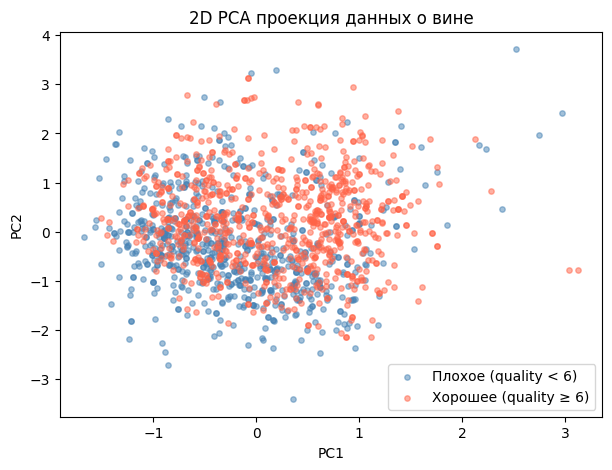

In [6]:
plt.figure(figsize=(7, 5))
for label, color, name in [(0, 'steelblue', 'Плохое (quality < 6)'),
                            (1, 'tomato',    'Хорошее (quality ≥ 6)')]:
    plt.scatter(X_pca[y_wine == label, 0], X_pca[y_wine == label, 1],
                color=color, alpha=0.5, s=15, label=name)
plt.legend(loc='best')
plt.title('2D PCA проекция данных о вине')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

### Метод «локтя» — выбор числа компонент

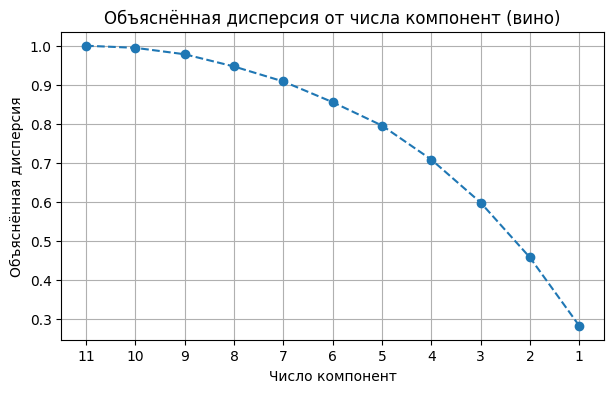

  1 компонент(ы): 0.2817
  2 компонент(ы): 0.4568
  3 компонент(ы): 0.5978
  4 компонент(ы): 0.7081
  5 компонент(ы): 0.7953
  6 компонент(ы): 0.8552
  7 компонент(ы): 0.9083
  8 компонент(ы): 0.9468
  9 компонент(ы): 0.9781
  10 компонент(ы): 0.9946
  11 компонент(ы): 1.0000


In [7]:
components_range = range(1, 12)
explained_vars = [
    PCA(n_components=i).fit(X_wine.copy()).explained_variance.real
    for i in components_range
]

plt.figure(figsize=(7, 4))
plt.plot(components_range, explained_vars, '--o')
plt.xlabel('Число компонент')
plt.ylabel('Объяснённая дисперсия')
plt.xticks(components_range)
plt.gca().invert_xaxis()
plt.title('Объяснённая дисперсия от числа компонент (вино)')
plt.grid(True)
plt.show()

for i, v in zip(components_range, explained_vars):
    print(f'  {i} компонент(ы): {v:.4f}')

### Реконструкция данных

In [8]:
X_reconstructed = pca.transform_inverse(X_pca)

print('Оригинал (первый объект):     ', np.round(X_wine[0], 3))
print('Реконструкция (первый объект):', np.round(X_reconstructed[0].real, 3))
print('\nСредняя ошибка реконструкции (MSE):',
      np.round(np.mean((X_wine - X_reconstructed.real)**2), 4))

Оригинал (первый объект):      [-0.528  0.962 -1.391 -0.453 -0.244 -0.466 -0.379  0.558  1.289 -0.579
 -0.96 ]
Реконструкция (первый объект): [-0.497  0.254 -0.473 -0.133 -0.206  0.094 -0.246  0.441 -0.385  0.005
  0.062]

Средняя ошибка реконструкции (MSE): 0.8632


---
## Часть 2. Eigenfaces — Labeled Faces in the Wild (LFW)

### Загрузка данных

Используем `fetch_lfw_people` с фильтром `min_faces_per_person=70` — оставляем только тех людей, у которых не менее 70 фотографий. Параметр `resize=0.6` уменьшает изображения до 60% исходного размера для ускорения вычислений.

In [9]:
lfw = fetch_lfw_people(min_faces_per_person=70, resize=0.6)
X, y, images = lfw.data, lfw.target, lfw.images
target_names = lfw.target_names

print('Форма данных:', X.shape)
print('Форма изображений:', images.shape)
print('Число людей:', len(target_names))
print()
for name, count in zip(target_names, np.bincount(y)):
    print(f'  {name}: {count} фото')

Форма данных: (1288, 4200)
Форма изображений: (1288, 75, 56)
Число людей: 7

  Ariel Sharon: 77 фото
  Colin Powell: 236 фото
  Donald Rumsfeld: 121 фото
  George W Bush: 530 фото
  Gerhard Schroeder: 109 фото
  Hugo Chavez: 71 фото
  Tony Blair: 144 фото


### Визуализация — по одному фото каждого человека

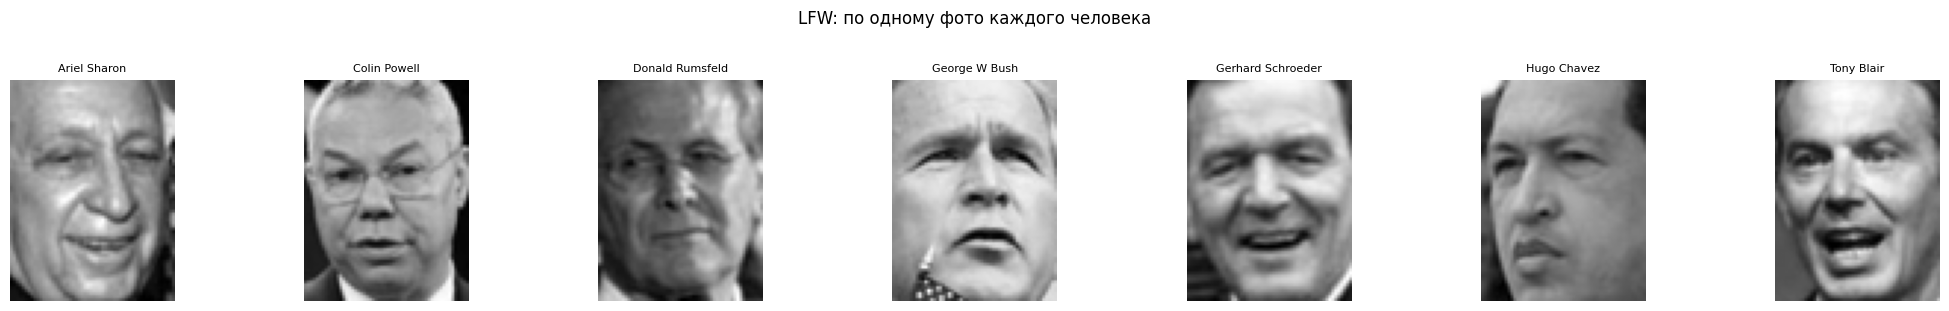

In [10]:
n_persons = len(target_names)
fig, axes = plt.subplots(1, n_persons, figsize=(3 * n_persons, 3))
if n_persons == 1:
    axes = [axes]

for i, person_id in enumerate(np.unique(y)):
    first_idx = np.where(y == person_id)[0][0]
    axes[i].imshow(images[first_idx], cmap='gray')
    axes[i].set_title(target_names[person_id], fontsize=8)
    axes[i].axis('off')

plt.suptitle('LFW: по одному фото каждого человека', y=1.02)
plt.tight_layout()
plt.show()

### Разбивка на обучающую и тестовую выборки

Для демонстрации распознавания используем ту же схему, что в лекции:
- **In-sample тест** — последнее фото первого человека (исключено из обучения, но этот человек присутствует в тренировочной выборке)
- **Out-of-sample тест** — первое фото последнего человека (этот человек полностью отсутствует в обучении)

In [11]:
unique_persons = np.unique(y)

# In-sample: последнее фото первого человека
in_person_id = unique_persons[0]
in_person_indices = np.where(y == in_person_id)[0]
in_sample_test_idx = in_person_indices[-1]

# Out-of-sample: первое фото последнего человека
out_person_id = unique_persons[-1]
out_sample_test_idx = np.where(y == out_person_id)[0][0]

# Обучающая выборка: всё кроме out-of-sample персоны и in-sample тест-фото
train_mask = np.ones(len(y), dtype=bool)
train_mask[y == out_person_id] = False
train_mask[in_sample_test_idx] = False

X_train      = X[train_mask]
y_train      = y[train_mask]
images_train = images[train_mask]

# Тестовая выборка
X_test      = np.array([X[in_sample_test_idx],      X[out_sample_test_idx]])
y_test      = np.array([y[in_sample_test_idx],      y[out_sample_test_idx]])
images_test = np.array([images[in_sample_test_idx], images[out_sample_test_idx]])

print(f'Обучающая выборка: {X_train.shape}')
print(f'Тестовая выборка:  {X_test.shape}')
print(f'In-sample  тест: {target_names[y_test[0]]}')
print(f'Out-of-sample тест: {target_names[y_test[1]]} (не присутствует в обучении)')

Обучающая выборка: (1143, 4200)
Тестовая выборка:  (2, 4200)
In-sample  тест: Ariel Sharon
Out-of-sample тест: Tony Blair (не присутствует в обучении)


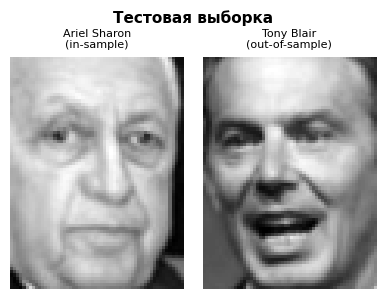

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(4, 3))
fig.suptitle('Тестовая выборка', size=11, weight='bold')
axes[0].imshow(images_test[0], cmap='gray')
axes[0].set_title(f'{target_names[y_test[0]]}\n(in-sample)', fontsize=8)
axes[0].axis('off')
axes[1].imshow(images_test[1], cmap='gray')
axes[1].set_title(f'{target_names[y_test[1]]}\n(out-of-sample)', fontsize=8)
axes[1].axis('off')
plt.tight_layout()
plt.show()

### Среднее лицо

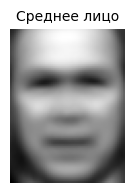

In [13]:
faceshape = images_train[0].shape
mean = np.mean(X_train, axis=0)

plt.figure(figsize=(2, 2))
plt.imshow(mean.reshape(faceshape), cmap='gray')
plt.title('Среднее лицо', size=10)
plt.axis('off')
plt.show()

### Ковариационная матрица и собственные векторы

Поскольку размерность признакового пространства $d$ (число пикселей) сопоставима или превышает число объектов $n$, вычисляем ковариацию через матрицу $X X^\top$ размера $n \times n$ вместо $X^\top X$ размера $d \times d$.

In [14]:
X_centered = X_train - mean
covariance_matrix = (X_centered @ X_centered.T) / (X_centered.shape[0] - 1)
print(f'Размерность признаков d = {X_train.shape[1]}, число объектов n = {X_train.shape[0]}')
print(f'Ковариационная матрица X·Xᵀ: {covariance_matrix.shape}')

Размерность признаков d = 4200, число объектов n = 1143
Ковариационная матрица X·Xᵀ: (1143, 1143)


In [15]:
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)
idxs = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idxs]
eigenvectors = eigenvectors[:, idxs]

# Преобразуем обратно в пространство пикселей
eigenvectors_converted = X_centered.T @ eigenvectors

# Нормализуем
eigenvectors_converted = eigenvectors_converted.T / np.sqrt(
    (eigenvectors_converted.T ** 2).sum(axis=1, keepdims=True)
)
print('Форма собственных векторов:', eigenvectors_converted.shape)

Форма собственных векторов: (1143, 4200)


### Объяснённая дисперсия — порог 90%

Компонент для объяснения 90% дисперсии: 99


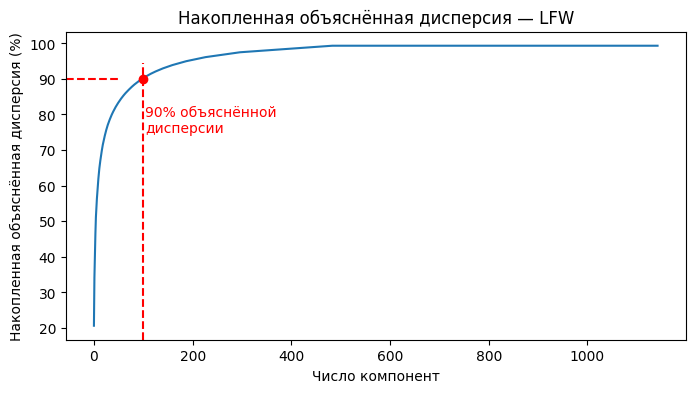

In [16]:
eigenvalues_real = np.abs(eigenvalues.real)
total = eigenvalues_real.sum()
explained_variance = np.round((eigenvalues_real / total) * 100, 2)
cumulative_explained_variance = np.cumsum(explained_variance)

variance_threshold = 90
n_components = np.argwhere(cumulative_explained_variance >= variance_threshold).min() + 1
print(f'Компонент для объяснения {variance_threshold}% дисперсии: {n_components}')

plt.figure(figsize=(8, 4))
plt.plot(cumulative_explained_variance)
plt.plot(n_components, variance_threshold, 'o', color='r')
plt.axhline(y=variance_threshold, xmax=n_components / len(cumulative_explained_variance),
            linestyle='--', color='r')
plt.axvline(x=n_components, ymax=variance_threshold / 100,
            linestyle='--', color='r')
plt.text(n_components + 5, 75, f'{variance_threshold}% объяснённой\nдисперсии', color='red')
plt.xlabel('Число компонент')
plt.ylabel('Накопленная объяснённая дисперсия (%)')
plt.title('Накопленная объяснённая дисперсия — LFW')
plt.show()

### Eigenfaces — первые 9 главных компонент

Eigenfaces: (99, 4200)


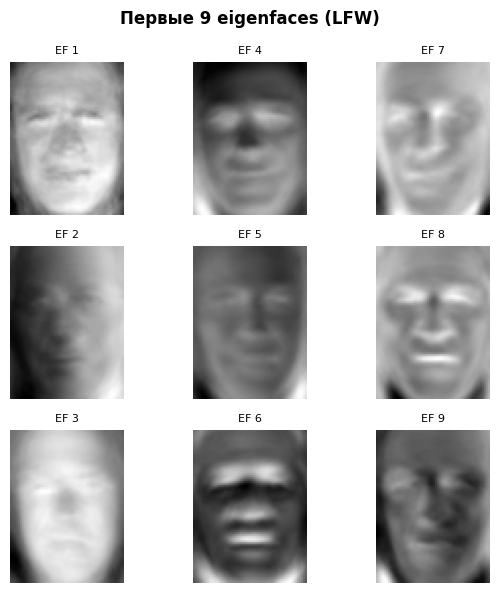

In [17]:
eigenfaces = eigenvectors_converted[:n_components].real
print(f'Eigenfaces: {eigenfaces.shape}')

fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for i in range(9):
    axes[i % 3][i // 3].imshow(eigenfaces[i].reshape(faceshape), cmap='gray')
    axes[i % 3][i // 3].set_title(f'EF {i+1}', fontsize=8)
    axes[i % 3][i // 3].axis('off')
plt.suptitle('Первые 9 eigenfaces (LFW)', weight='bold')
plt.tight_layout()
plt.show()

### Проецирование обучающих данных

In [18]:
weights = eigenfaces @ (X_train - mean).T
print('Форма матрицы весов:', weights.shape)

Форма матрицы весов: (99, 1143)


### Распознавание: in-sample тест

Проецируем тестовое лицо на пространство eigenfaces и находим ближайшее по евклидовому расстоянию лицо из обучающей выборки.

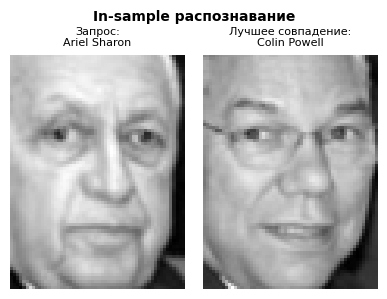

Совпадение верное: False


In [19]:
in_sample_query = X_test[0].reshape(1, -1)
in_sample_weight = eigenfaces @ (in_sample_query - mean).T
euclidean_distance = np.linalg.norm(weights - in_sample_weight, axis=0)
in_sample_best_match = np.argmin(euclidean_distance)

fig, axes = plt.subplots(1, 2, figsize=(4, 3))
fig.suptitle('In-sample распознавание', size=10, weight='bold')
axes[0].imshow(images_test[0], cmap='gray')
axes[0].set_title(f'Запрос:\n{target_names[y_test[0]]}', fontsize=8)
axes[0].axis('off')
axes[1].imshow(images_train[in_sample_best_match], cmap='gray')
axes[1].set_title(f'Лучшее совпадение:\n{target_names[y_train[in_sample_best_match]]}', fontsize=8)
axes[1].axis('off')
plt.tight_layout()
plt.show()

correct = target_names[y_test[0]] == target_names[y_train[in_sample_best_match]]
print('Совпадение верное:', correct)

### Распознавание: out-of-sample тест

Человек, чьё лицо мы ищем, **отсутствует в обучающей выборке**. Модель найдёт наиболее похожее лицо из известных ей людей — совпадение по имени будет неверным, но визуально результат покажет, на кого похож этот человек по мнению eigenfaces.

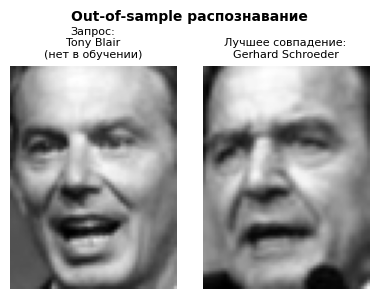

Искали: Tony Blair
Нашли:  Gerhard Schroeder


In [20]:
out_sample_query = X_test[1].reshape(1, -1)
out_sample_weight = eigenfaces @ (out_sample_query - mean).T
euclidean_distance = np.linalg.norm(weights - out_sample_weight, axis=0)
out_sample_best_match = np.argmin(euclidean_distance)

fig, axes = plt.subplots(1, 2, figsize=(4, 3))
fig.suptitle('Out-of-sample распознавание', size=10, weight='bold')
axes[0].imshow(images_test[1], cmap='gray')
axes[0].set_title(f'Запрос:\n{target_names[y_test[1]]}\n(нет в обучении)', fontsize=8)
axes[0].axis('off')
axes[1].imshow(images_train[out_sample_best_match], cmap='gray')
axes[1].set_title(f'Лучшее совпадение:\n{target_names[y_train[out_sample_best_match]]}', fontsize=8)
axes[1].axis('off')
plt.tight_layout()
plt.show()

print(f'Искали: {target_names[y_test[1]]}')
print(f'Нашли:  {target_names[y_train[out_sample_best_match]]}')